# Predictive Maintenance with Machine Learning

Most machines such as wind turbines, turbofans and engines have certian lifespans before breaking down. The reasons for the breakdwon can range from various problems such as heat and mechanical stress/overload. A predictive maintenance model will help determine when a machine is nearing its lifespan or is prone to damage based on specific performance metrics and can be called in early for maintenance. This avoids machine break downs to reduce repair costs and cuts down on downtimes to maximise asset utilisation

# Dataset
Source: [AI4I 2020 Predictive Maintenance Dataset](https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset) (UCI Machine Learning Repository)

# Approach
1. Exploratory data analysis and outlier detection
2. Feature engineering (temperature differential, mechancial power)
3. Class imbalacne handling with SMOTE
4. Model comparison: Logistic Regression, Random Forest, Histrogram Gradient Boosting
5. Evaluate using precision, recall, F1-score, and ROC-AUC
6. Feature importance analysis with SHAP

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(r"ai4i2020.csv")

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
#check for missing data 
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


# exploratory data analysis 
- there are 10 000 records with no missing values
- average air and process temperature, 300K and 310K respectively
- both rotational speed and torque have wide variance (1168 rpm - 2886 rpm and 3.8 Nm - 76.6 Nm). It is worth checking for potential outliers
- target variable 'Machine failure' is heavily imbalanced. Failures are expected to be rare. 

array([[<Axes: title={'center': 'UDI'}>,
        <Axes: title={'center': 'Air temperature [K]'}>,
        <Axes: title={'center': 'Process temperature [K]'}>],
       [<Axes: title={'center': 'Rotational speed [rpm]'}>,
        <Axes: title={'center': 'Torque [Nm]'}>,
        <Axes: title={'center': 'Tool wear [min]'}>],
       [<Axes: title={'center': 'Machine failure'}>,
        <Axes: title={'center': 'TWF'}>, <Axes: title={'center': 'HDF'}>],
       [<Axes: title={'center': 'PWF'}>, <Axes: title={'center': 'OSF'}>,
        <Axes: title={'center': 'RNF'}>]], dtype=object)

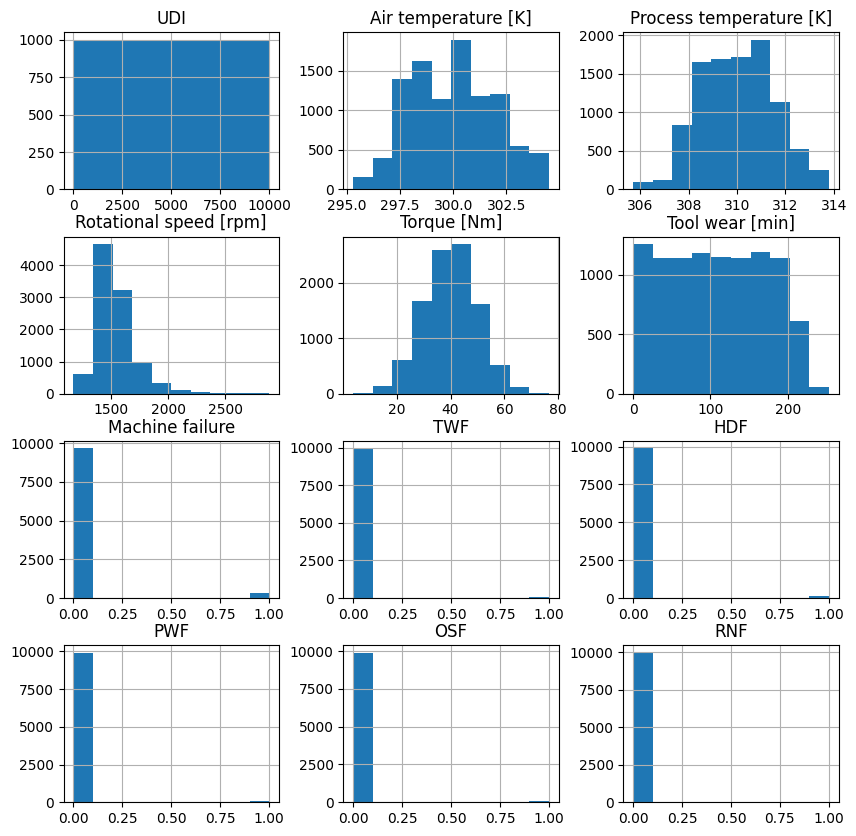

In [6]:
df.hist(figsize=(10,10))

In [7]:
#class distribution
df["Machine failure"].unique()
#most machines built to last, failure (1) should be less than non-failure (0)
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

<Axes: xlabel='Machine failure', ylabel='count'>

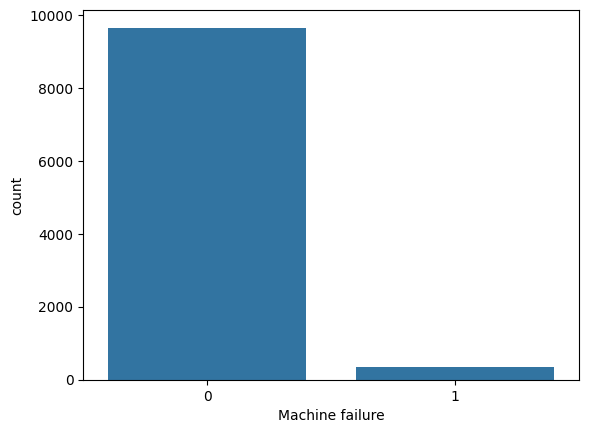

In [8]:
sns.countplot(x='Machine failure', data = df)

Only 339 out of 10 000 machines (3.4%) experienced failure meaning more focus on recall and F1-scored required since a model predicting no failure would score ~96.6%

In [9]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [10]:
#type of failure

failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
def machine_failure_type(row):
    for col in failure_cols:
        if row[col] == 1:
            return col 
    return 'No Failure'

In [11]:
df['Failure Type'] = df.apply(machine_failure_type, axis = 1)

In [12]:
df['Failure Type']

0       No Failure
1       No Failure
2       No Failure
3       No Failure
4       No Failure
           ...    
9995    No Failure
9996    No Failure
9997    No Failure
9998    No Failure
9999    No Failure
Name: Failure Type, Length: 10000, dtype: str

<Axes: xlabel='Failure Type', ylabel='count'>

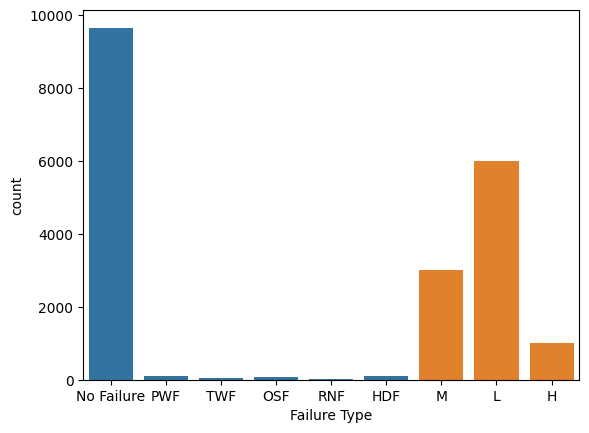

In [13]:
#visualising different types of failures
sns.countplot(x = 'Failure Type', data = df)
sns.countplot(x = 'Type', data = df)


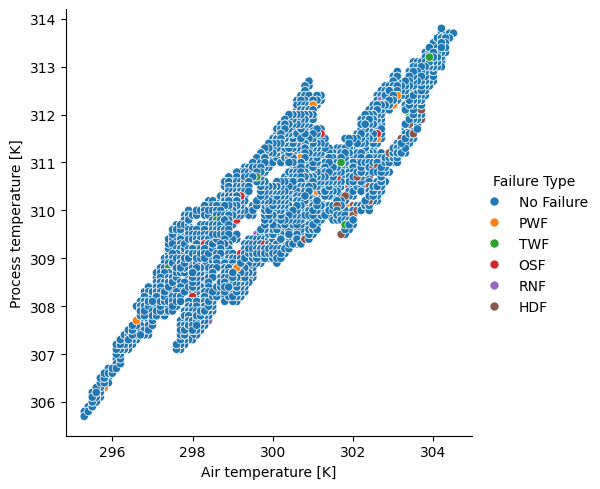

In [14]:
sns.relplot(x = 'Air temperature [K]', y='Process temperature [K]', hue = 'Failure Type', sizes=(100,5), data = df)

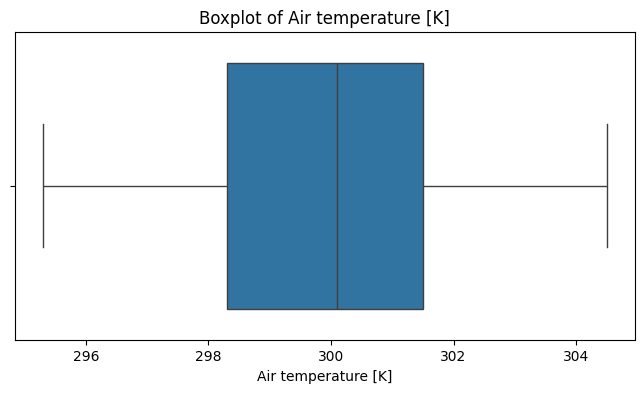

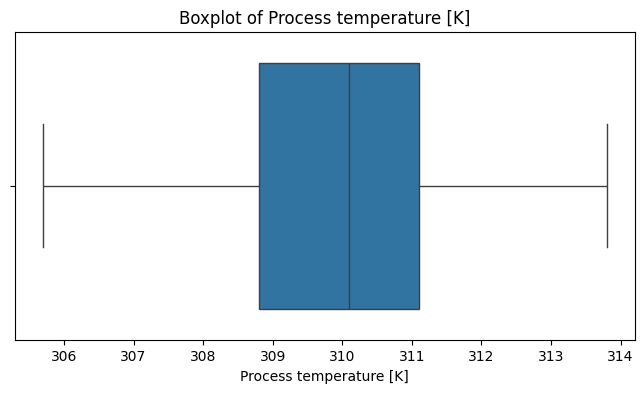

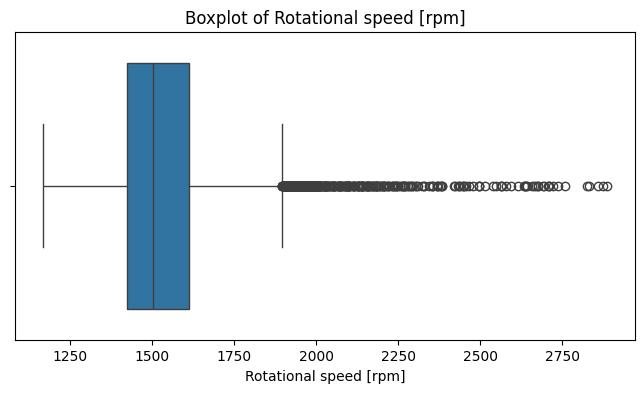

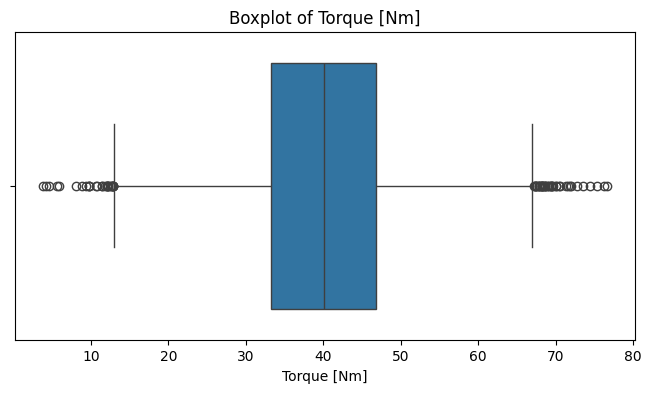

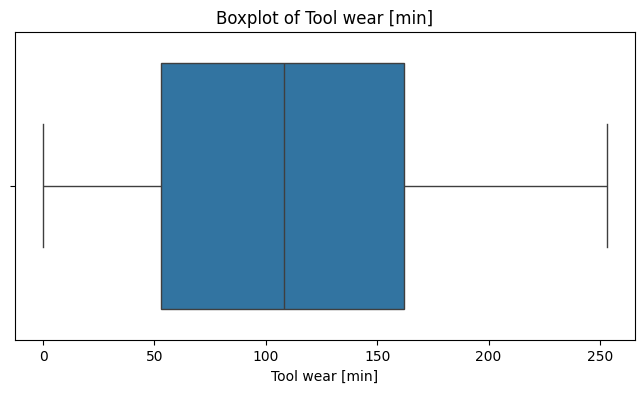

In [15]:
#outlier detection, boxplot
sensor_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
               'Torque [Nm]', 'Tool wear [min]']
for col in sensor_cols: 
    plt.figure(figsize = (8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

+ Torque and rotational speed had significantly more outliers (outside quartile ranges) than other metrics

In [16]:
#feature engineering and ML

df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Failure Type'],
      dtype='str')

In [17]:
df['Type'].unique()

<StringArray>
['M', 'L', 'H']
Length: 3, dtype: str

In [18]:
df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

In [19]:
df['Temp diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]'] 

In [20]:
feature_cols = ['Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Temp diff', 'Power']
xfeatures = df[feature_cols]
ylabels = df['Machine failure']

Temp diff

Temperature differential help us identify heat dissipation issues. We know that machines generate heat while operating, and this results in process temperature to be higher than its surrounding air temperature. Heat naturally flows from hot to cold so a larger difference between process temp and air temp would mean heat can dissipate to the surrounding air at a faster rate, allowing for more efficient dissipation. A small difference would signal danger because it reduces the rate of heat flow since the surrounding air temp is already close to the process temp. This will help identify HDF (Heat Dissipation Failure) failures.

Power

Helps identify PWF (Power failure) and OSF (Overstrain). WIll help find a range where the machine should operate at. Anything above or below this range should signal danger.



In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [22]:
x_train, x_test, y_train, y_test = train_test_split(xfeatures, ylabels, test_size = 0.25, random_state = 42)

In [25]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

smote = SMOTE(random_state = 42)
x_train, y_train = smote.fit_resample(x_train, y_train)
print(f'After SMOTE - training set: {len(x_train)}, failure ratio: {y_train.mean():.2%}')

After SMOTE - training set: 14466, failure ratio: 50.00%


In [26]:
df['Type'].head() #test

0    1
1    0
2    0
3    0
4    0
Name: Type, dtype: int64

In [28]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

def build_and_evaluate(classifier, name, x_train, y_train, x_test, y_test):
    classifier.fit(x_train, y_train)
    y_pred = classifier.predict(x_test)
    y_proba = classifier.predict_proba(x_test)[:, 1]
   
    print(f'{name}')
    print(classification_report(y_test, y_pred))
    print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')
    
    fig, axes = plt.subplots(1, 2, figsize = (12, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax = axes[0])
    axes[0].set_title(f'{name} - Confusion Matrix')
    RocCurveDisplay.from_predictions(y_test, y_proba, ax = axes[1])
    axes[1].set_title(f'{name} - ROC Curve')
    plt.tight_layout()
    plt.show()
    
    return classifier, roc_auc_score(y_test, y_proba)


Random Forest
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2428
           1       0.63      0.79      0.70        72

    accuracy                           0.98      2500
   macro avg       0.81      0.89      0.84      2500
weighted avg       0.98      0.98      0.98      2500

ROC-AUC: 0.9756


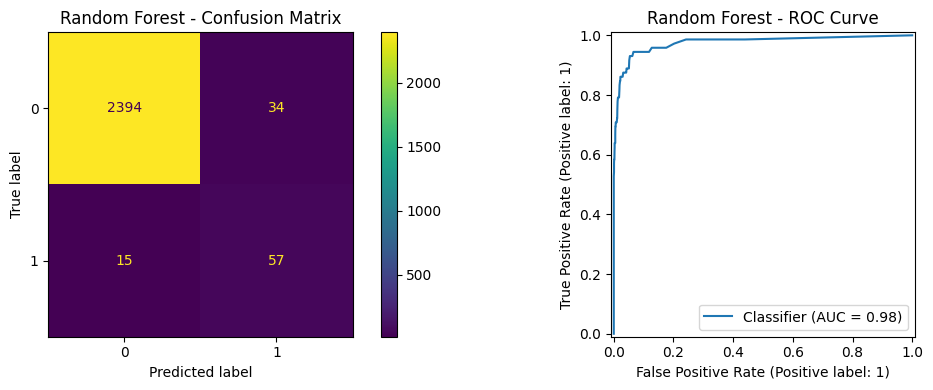


Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      2428
           1       0.16      0.79      0.26        72

    accuracy                           0.87      2500
   macro avg       0.57      0.83      0.59      2500
weighted avg       0.97      0.87      0.91      2500

ROC-AUC: 0.9179


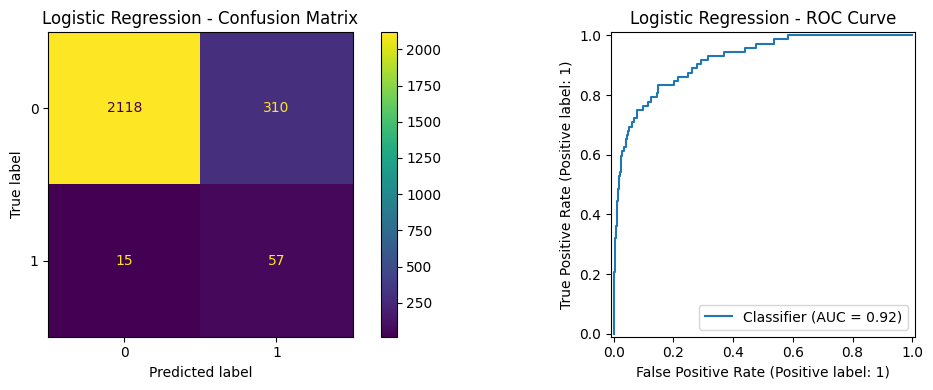


Histogram Gradient Boosting
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2428
           1       0.59      0.82      0.69        72

    accuracy                           0.98      2500
   macro avg       0.79      0.90      0.84      2500
weighted avg       0.98      0.98      0.98      2500

ROC-AUC: 0.9759


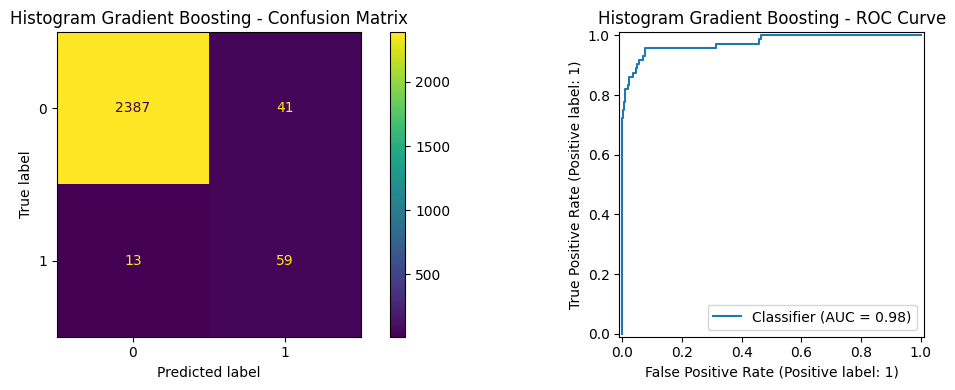

In [32]:
from sklearn.ensemble import HistGradientBoostingClassifier
rf_clf, rf_auc = build_and_evaluate(
    RandomForestClassifier(n_estimators = 100, random_state = 42),
    "Random Forest", x_train, y_train, x_test, y_test)

lr_clf, lr_auc = build_and_evaluate(
    LogisticRegression(max_iter = 1000),
    "Logistic Regression", x_train, y_train, x_test, y_test)

hgb_clf, hgb_auc = build_and_evaluate(
    HistGradientBoostingClassifier(random_state = 42),
    "Histogram Gradient Boosting", x_train, y_train, x_test, y_test)



In [40]:
#hgb optimisation
from sklearn.model_selection import RandomizedSearchCV

hgb_params = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [5, 10, 20, 30],
    'max_iter': [100, 200, 300]
}

hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state = 42),
    hgb_params, n_iter = 20, cv = 5,
    scoring='f1', random_state = 42, n_jobs =-1
)
hgb_search.fit(x_train, y_train)
print(f"Best params: {hgb_search.best_params_}")
print(f"Best F1: {hgb_search.best_score_:.4f}")

Best params: {'min_samples_leaf': 30, 'max_iter': 300, 'max_depth': 10, 'learning_rate': 0.1}
Best F1: 0.9902



Tuned Histogram Gradient Boosting
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2428
           1       0.63      0.82      0.72        72

    accuracy                           0.98      2500
   macro avg       0.81      0.90      0.85      2500
weighted avg       0.98      0.98      0.98      2500

ROC-AUC: 0.9649


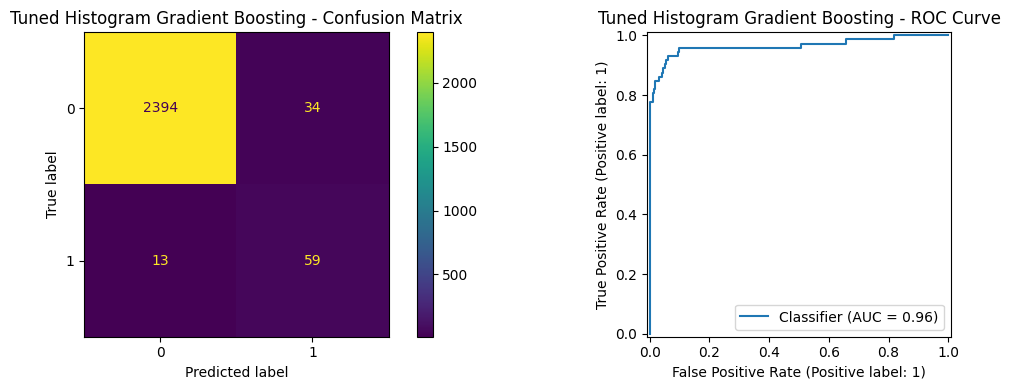

In [41]:
best_clf, best_auc = build_and_evaluate(
    hgb_search.best_estimator_,
    "Tuned Histogram Gradient Boosting", x_train, y_train, x_test, y_test)


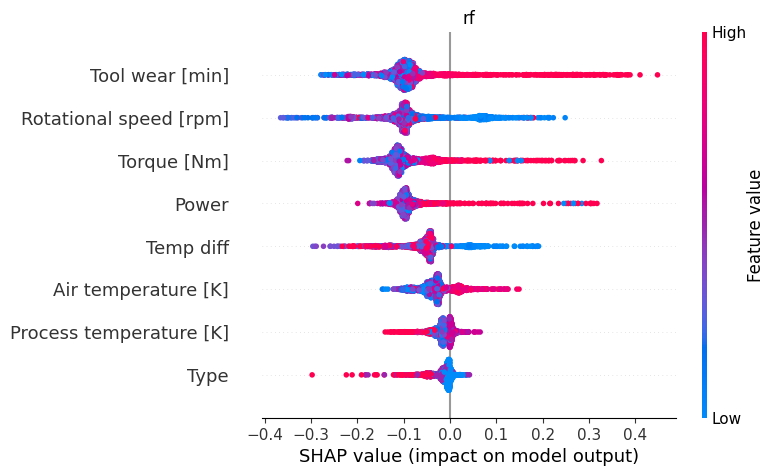

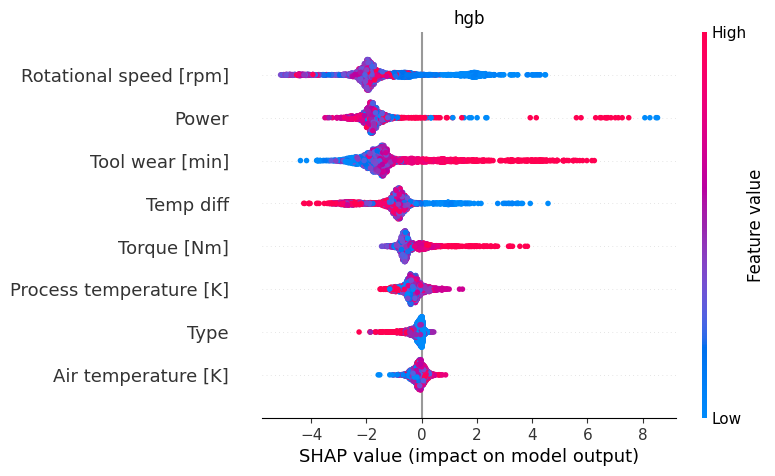

In [39]:

import shap

rf_explainer = shap.TreeExplainer(rf_clf)
rf_shap = rf_explainer(x_test)
shap.summary_plot(rf_shap[:, :, 1], x_test, feature_names = feature_cols, show = False)
plt.title('rf')
plt.show()

hgb_explainer = shap.TreeExplainer(hgb_clf)
hgb_shap = hgb_explainer(x_test)
shap.summary_plot(hgb_shap, x_test, feature_names = feature_cols, show = False)
plt.title('hgb')
plt.show()

## Conclusion
- tool wear, rotational speed, torque and power are the most important features for both RF and HGB
- engineered features (temp differential and mechanical power) both rank in top 5 for both models with power coming in 2nd for HGB, confirming their value
- temperature differential was more predictive than both air temperature and process temperature suggesting that heat dissipation issues are a key driver of machine failure, specifically heat dissipation failure (HDF) since it is amongst the most frequent failures. 
## Hyperparameter Tuning
Tuning improved precision on failure cases from 0.59 to 0.63 and F1 from 0.69 to 0.72, while maintaining the same recall (0.82). ROC-AUC dropped slightly from 0.976 to 0.965. This tradeoff is acceptable in a maintenance context. The tuned model captures the same proportion of real failures but triggers less false alarms 

## Future work
- test additional models
- build a simple deployment pipeline